#**Lab-to-Field Crop Disease Domain Generalisation Benchmark**


In [4]:
# ── CELL 0: Mount Drive + Python path ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append('/content/drive/MyDrive/idea4drive')
print('Drive mounted. sys.path updated.')

Mounted at /content/drive
Drive mounted. sys.path updated.


In [2]:
!ls

 drive		 plantdoc_aligned	 plantvillage-dataset.zip
 final_dataset	'plantvillage dataset'	 sample_data


In [3]:
# ── CELL 1: Reload all modules (run after any .py edit) ─────────────────
import importlib
import data_pipeline, model, train, evaluate, domain_gap

importlib.reload(data_pipeline)
importlib.reload(model)
importlib.reload(train)
importlib.reload(evaluate)
importlib.reload(domain_gap)
print('All modules reloaded.')

All modules reloaded.


In [4]:
# ── CELL 2: Kaggle setup from Drive ─────────────────────────────────────
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/idea4drive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle setup done.')

Kaggle setup done.


In [5]:
# ── CELL 3: Install dependencies ────────────────────────────────────────
!pip install kaggle scikit-learn matplotlib seaborn --quiet
print('Dependencies installed.')

Dependencies installed.


In [6]:
# ── CELL 4: Download PlantVillage (skip if already downloaded) ──────────
import os
if not os.path.exists('/content/plantvillage dataset/color'):
    print('Downloading PlantVillage...')
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset
    !unzip -q plantvillage-dataset.zip
    print('Download + unzip done.')
else:
    print('PlantVillage already present, skipping download.')

PlantVillage already present, skipping download.


In [7]:
# ── CELL 5: Verify PlantDoc is in Drive ─────────────────────────────────
import os
pd_train = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/train'
pd_test  = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/test'
pv_color = '/content/plantvillage dataset/color'

for p, label in [(pv_color, 'PlantVillage color'), (pd_train, 'PlantDoc train'), (pd_test, 'PlantDoc test')]:
    exists = os.path.isdir(p)
    count  = len(os.listdir(p)) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}]  {label}: {p}  ({count} entries)')

if not os.path.isdir(pv_color):
    raise RuntimeError('PlantVillage not found — run Cell 4 first.')
if not os.path.isdir(pd_train):
    raise RuntimeError('PlantDoc not found in Drive — upload PlantDoc-Dataset-master to idea4drive.')

  [OK]  PlantVillage color: /content/plantvillage dataset/color  (38 entries)
  [OK]  PlantDoc train: /content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/train  (29 entries)
  [OK]  PlantDoc test: /content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/test  (28 entries)


In [8]:
# ── CELL 6: Class alignment + build final_dataset (PV) + plantdoc_aligned (PD)
# This is the KEY FIX: builds BOTH datasets in one idempotent cell.
# Re-run safely after session restart — checks existence before copying.

import re, os, json, shutil, random
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
PV_PATH       = '/content/plantvillage dataset/color'
PD_TRAIN_PATH = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/train'
PD_TEST_PATH  = '/content/drive/MyDrive/idea4drive/PlantDoc-Dataset-master/test'

# Output dirs (ephemeral /content/ — rebuilt each session)
FINAL_TRAIN   = '/content/final_dataset/train'
FINAL_VAL     = '/content/final_dataset/val'
PD_ALIGNED_VAL = '/content/plantdoc_aligned/val'

EXCLUDE = {'.ds_store', 'ds_store', 'thumbs.db', '.thumbs'}

def load_classes(path):
    return [
        c for c in os.listdir(path)
        if os.path.isdir(os.path.join(path, c))
        and c.lower().strip() not in EXCLUDE
        and not c.startswith('.')
    ]

def clean_name(name: str) -> str:
    name = name.lower()
    name = re.sub(r'\bleaf\b', '', name)
    name = re.sub(r'[^a-z0-9]', '_', name)
    name = re.sub(r'_+', '_', name)
    return name.strip('_')

# ── Canonical mapping ──────────────────────────────────────────────────────
mapping = {
    'tomato_early_blight': 'tomato_early_blight',
    'tomato___early_blight': 'tomato_early_blight',
    'tomato_late_blight': 'tomato_late_blight',
    'tomato___late_blight': 'tomato_late_blight',
    'tomato_bacterial_spot': 'tomato_bacterial_spot',
    'tomato___bacterial_spot': 'tomato_bacterial_spot',
    'tomato_septoria_spot': 'tomato_septoria_leaf_spot',
    'tomato_septoria_leaf_spot': 'tomato_septoria_leaf_spot',
    'tomato___septoria_leaf_spot': 'tomato_septoria_leaf_spot',
    'tomato___septoria_spot': 'tomato_septoria_leaf_spot',
    'tomato_mold': 'tomato_leaf_mold',
    'tomato_leaf_mold': 'tomato_leaf_mold',
    'tomato__leaf_mold': 'tomato_leaf_mold',
    'tomato___leaf_mold': 'tomato_leaf_mold',
    'tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato_tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato___tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato__tomato_mosaic_virus': 'tomato_mosaic_virus',
    'tomato_yellow_leaf_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_yellow_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_tomato_yellow_leaf_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_tomato_yellow_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato___tomato_yellow_curl_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_yellow_virus': 'tomato_yellow_leaf_curl_virus',
    'tomato_spider_mites': 'tomato_spider_mites',
    'tomato_spider_mites_two_spotted': 'tomato_spider_mites',
    'tomato___spider_mites_two_spotted': 'tomato_spider_mites',
    'tomato_spider_mites_two_spotted_spider_mite': 'tomato_spider_mites',
    'tomato_two_spotted_spider_mites': 'tomato_spider_mites',
    'tomato_target_spot': 'tomato_target_spot',
    'tomato__target_spot': 'tomato_target_spot',
    'tomato___target_spot': 'tomato_target_spot',
    'tomato_healthy': 'tomato_healthy',
    'tomato___healthy': 'tomato_healthy',
    'potato_early_blight': 'potato_early_blight',
    'potato___early_blight': 'potato_early_blight',
    'potato_late_blight': 'potato_late_blight',
    'potato___late_blight': 'potato_late_blight',
    'potato_healthy': 'potato_healthy',
    'potato___healthy': 'potato_healthy',
    'corn_common_rust': 'corn_common_rust',
    'maize_common_rust': 'corn_common_rust',
    'corn___common_rust': 'corn_common_rust',
    'corn_maize_common_rust': 'corn_common_rust',
    'corn_rust': 'corn_common_rust',
    'corn_northern_blight': 'corn_northern_leaf_blight',
    'corn_northern_leaf_blight': 'corn_northern_leaf_blight',
    'maize_northern_leaf_blight': 'corn_northern_leaf_blight',
    'corn___northern_leaf_blight': 'corn_northern_leaf_blight',
    'corn_maize_northern_leaf_blight': 'corn_northern_leaf_blight',
    'corn_maize_northern_blight': 'corn_northern_leaf_blight',
    'corn_blight': 'corn_northern_leaf_blight',
    'corn_gray_leaf_spot': 'corn_gray_leaf_spot',
    'maize_gray_leaf_spot': 'corn_gray_leaf_spot',
    'corn___gray_leaf_spot': 'corn_gray_leaf_spot',
    'corn___cercospora_spot_gray': 'corn_gray_leaf_spot',
    'corn_maize_cercospora_leaf_spot_gray_leaf_spot': 'corn_gray_leaf_spot',
    'corn_maize_cercospora_spot_gray_spot': 'corn_gray_leaf_spot',
    'corn_gray_spot': 'corn_gray_leaf_spot',
    'corn_healthy': 'corn_healthy',
    'maize_healthy': 'corn_healthy',
    'corn___healthy': 'corn_healthy',
    'corn_maize_healthy': 'corn_healthy',
    'apple_scab': 'apple_scab',
    'apple_apple_scab': 'apple_scab',
    'apple___apple_scab': 'apple_scab',
    'apple_black_rot': 'apple_black_rot',
    'apple___black_rot': 'apple_black_rot',
    'apple_cedar_rust': 'apple_cedar_rust',
    'apple_cedar_apple_rust': 'apple_cedar_rust',
    'apple___cedar_apple_rust': 'apple_cedar_rust',
    'apple_rust': 'apple_cedar_rust',
    'apple_healthy': 'apple_healthy',
    'apple___healthy': 'apple_healthy',
    'grape_black_rot': 'grape_black_rot',
    'grape___black_rot': 'grape_black_rot',
    'grape_esca': 'grape_esca',
    'grape_esca_black_measles': 'grape_esca',
    'grape___esca_black_measles': 'grape_esca',
    'grape_isariopsis_blight': 'grape_leaf_blight',
    'grape_leaf_blight': 'grape_leaf_blight',
    'grape___isariopsis_blight': 'grape_leaf_blight',
    'grape_leaf_blight_isariopsis_leaf_spot': 'grape_leaf_blight',
    'grape_blight_isariopsis_spot': 'grape_leaf_blight',
    'grape___blight_isariopsis_spot': 'grape_leaf_blight',
    'grape_healthy': 'grape_healthy',
    'grape___healthy': 'grape_healthy',
    'pepper_bell_bacterial_spot': 'pepper_bacterial_spot',
    'pepper___bell___bacterial_spot': 'pepper_bacterial_spot',
    'pepper_bacterial_spot': 'pepper_bacterial_spot',
    'pepper_bell_healthy': 'pepper_healthy',
    'pepper___bell___healthy': 'pepper_healthy',
    'pepper_healthy': 'pepper_healthy',
    'bell_pepper_healthy': 'pepper_healthy',
    'squash_powdery_mildew': 'squash_powdery_mildew',
    'squash___powdery_mildew': 'squash_powdery_mildew',
    'strawberry_scorch': 'strawberry_leaf_scorch',
    'strawberry_leaf_scorch': 'strawberry_leaf_scorch',
    'strawberry___leaf_scorch': 'strawberry_leaf_scorch',
    'strawberry___scorch': 'strawberry_leaf_scorch',
    'strawberry_healthy': 'strawberry_healthy',
    'strawberry___healthy': 'strawberry_healthy',
    'peach_bacterial_spot': 'peach_bacterial_spot',
    'peach___bacterial_spot': 'peach_bacterial_spot',
    'peach_healthy': 'peach_healthy',
    'peach___healthy': 'peach_healthy',
    'cherry_powdery_mildew': 'cherry_powdery_mildew',
    'cherry___powdery_mildew': 'cherry_powdery_mildew',
    'cherry_including_sour_powdery_mildew': 'cherry_powdery_mildew',
    'cherry_healthy': 'cherry_healthy',
    'cherry___healthy': 'cherry_healthy',
    'cherry_including_sour_healthy': 'cherry_healthy',
    'blueberry_healthy': 'blueberry_healthy',
    'blueberry___healthy': 'blueberry_healthy',
    'raspberry_healthy': 'raspberry_healthy',
    'raspberry___healthy': 'raspberry_healthy',
    'soybean_healthy': 'soybean_healthy',
    'soybean___healthy': 'soybean_healthy',
    'orange_haunglongbing_citrus_greening': 'orange_huanglongbing',
    'orange___haunglongbing_citrus_greening': 'orange_huanglongbing',
}

# ── Compute common classes ─────────────────────────────────────────────────
pv_classes = load_classes(PV_PATH)
pd_classes = list(set(load_classes(PD_TRAIN_PATH)) | set(load_classes(PD_TEST_PATH)))

pv_clean = [clean_name(c) for c in pv_classes]
pd_clean = [clean_name(c) for c in pd_classes]

pv_mapped = [mapping.get(c, c) for c in pv_clean]
pd_mapped = [mapping.get(c, c) for c in pd_clean]

common_classes = set(pv_mapped) & set(pd_mapped)

class_to_idx = {cls: idx for idx, cls in enumerate(sorted(common_classes))}

print(f'Common classes found: {len(common_classes)}')
for c in sorted(common_classes):
    print(f'  [{class_to_idx[c]:2d}]  {c}')

# ── Helper: copy images from a raw source folder ───────────────────────────
def copy_images_from_folder(src_folder, dst_folder):
    """Copy all valid images from src_folder to dst_folder."""
    os.makedirs(dst_folder, exist_ok=True)
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}
    copied = 0
    for fname in os.listdir(src_folder):
        if fname.startswith('.'):
            continue
        if Path(fname).suffix.lower() not in valid_ext:
            continue
        src = os.path.join(src_folder, fname)
        dst = os.path.join(dst_folder, fname)
        if not os.path.exists(dst):  # skip if already copied (idempotent)
            shutil.copy2(src, dst)
        copied += 1
    return copied

# ── BUILD 1: final_dataset (PlantVillage → train 80% / val 20%) ────────────
print('\n' + '='*60)
print('BUILDING final_dataset (PlantVillage) ...')
print('='*60)

random.seed(42)
for cls in common_classes:
    os.makedirs(os.path.join(FINAL_TRAIN, cls), exist_ok=True)
    os.makedirs(os.path.join(FINAL_VAL,   cls), exist_ok=True)

pv_total = 0
for raw, cleaned in zip(pv_classes, pv_clean):
    canonical = mapping.get(cleaned, cleaned)
    if canonical not in common_classes:
        continue
    src_dir   = os.path.join(PV_PATH, raw)
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}
    images    = [
        f for f in os.listdir(src_dir)
        if not f.startswith('.') and Path(f).suffix.lower() in valid_ext
    ]
    for img in images:
        src = os.path.join(src_dir, img)
        if random.random() < 0.8:
            dst = os.path.join(FINAL_TRAIN, canonical, img)
        else:
            dst = os.path.join(FINAL_VAL, canonical, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        pv_total += 1

train_count = sum(len(os.listdir(os.path.join(FINAL_TRAIN, c))) for c in common_classes if os.path.isdir(os.path.join(FINAL_TRAIN, c)))
val_count   = sum(len(os.listdir(os.path.join(FINAL_VAL,   c))) for c in common_classes if os.path.isdir(os.path.join(FINAL_VAL,   c)))
print(f'final_dataset built:  train={train_count} images | val={val_count} images')

# ── BUILD 2: plantdoc_aligned/val (PlantDoc test+train → val only) ─────────
# KEY FIX: PlantDoc is the TARGET domain eval set. We use ALL PlantDoc images
# (train+test) as the eval split — no PlantDoc images are ever used for training.
# This maintains strict source/target separation.
print('\n' + '='*60)
print('BUILDING plantdoc_aligned/val (PlantDoc target domain) ...')
print('='*60)

os.makedirs(PD_ALIGNED_VAL, exist_ok=True)
for cls in common_classes:
    os.makedirs(os.path.join(PD_ALIGNED_VAL, cls), exist_ok=True)

pd_total = 0
for pd_base in [PD_TRAIN_PATH, PD_TEST_PATH]:
    for raw in load_classes(pd_base):
        cleaned   = clean_name(raw)
        canonical = mapping.get(cleaned, cleaned)
        if canonical not in common_classes:
            continue
        src_dir = os.path.join(pd_base, raw)
        dst_dir = os.path.join(PD_ALIGNED_VAL, canonical)
        n = copy_images_from_folder(src_dir, dst_dir)
        pd_total += n

pd_count = sum(len(os.listdir(os.path.join(PD_ALIGNED_VAL, c))) for c in common_classes if os.path.isdir(os.path.join(PD_ALIGNED_VAL, c)))
print(f'plantdoc_aligned/val built: {pd_count} images across {len(common_classes)} classes')

# ── Verify both datasets ───────────────────────────────────────────────────
print('\n' + '='*60)
print('DATASET VERIFICATION')
print('='*60)
for label, path in [('PV train', FINAL_TRAIN), ('PV val', FINAL_VAL), ('PD aligned val', PD_ALIGNED_VAL)]:
    classes_present = [c for c in common_classes if os.path.isdir(os.path.join(path, c)) and len(os.listdir(os.path.join(path, c))) > 0]
    total_imgs = sum(len(os.listdir(os.path.join(path, c))) for c in classes_present)
    print(f'  {label:20s}: {len(classes_present):2d} classes | {total_imgs:6d} images')

# ── Save alignment artefacts ───────────────────────────────────────────────
out_dir = '/content/drive/MyDrive/idea4drive/alignment_outputs'
os.makedirs(out_dir, exist_ok=True)
with open(f'{out_dir}/class_to_idx.json', 'w') as f:
    json.dump(class_to_idx, f, indent=2)
with open(f'{out_dir}/common_classes.txt', 'w') as f:
    f.write('\n'.join(sorted(common_classes)))
print(f'\nAlignment artefacts saved to {out_dir}')
print('\nAll datasets ready. Proceed to Cell 7.')

Common classes found: 17
  [ 0]  apple_cedar_rust
  [ 1]  apple_scab
  [ 2]  corn_common_rust
  [ 3]  corn_gray_leaf_spot
  [ 4]  corn_northern_leaf_blight
  [ 5]  grape_black_rot
  [ 6]  potato_early_blight
  [ 7]  potato_late_blight
  [ 8]  squash_powdery_mildew
  [ 9]  tomato_bacterial_spot
  [10]  tomato_early_blight
  [11]  tomato_late_blight
  [12]  tomato_leaf_mold
  [13]  tomato_mosaic_virus
  [14]  tomato_septoria_leaf_spot
  [15]  tomato_spider_mites
  [16]  tomato_yellow_leaf_curl_virus

BUILDING final_dataset (PlantVillage) ...
final_dataset built:  train=19032 images | val=4743 images

BUILDING plantdoc_aligned/val (PlantDoc target domain) ...
plantdoc_aligned/val built: 1679 images across 17 classes

DATASET VERIFICATION
  PV train            : 17 classes |  19032 images
  PV val              : 17 classes |   4743 images
  PD aligned val      : 17 classes |   1679 images

Alignment artefacts saved to /content/drive/MyDrive/idea4drive/alignment_outputs

All datasets ready.

In [9]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Add your project folder to Python path
import sys
sys.path.append('/content/drive/MyDrive/idea4drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# ── CELL 7: Pipeline verification ───────────────────────────────────────
from data_pipeline import build_dataloaders, verify_pipeline

verify_pipeline(
    '/content/final_dataset/train',
    '/content/final_dataset/val'
)

In [11]:
# ── CELL 8: Train (source domain only — PlantVillage) ──────────────────────
#
# AUTO-DETECTS GPU vs CPU and adjusts settings accordingly:
#
#   GPU (T4):  efficientnet_b0, batch_size=64, ~2-3 min/epoch, 15 epochs total
#   CPU:       mobilenet_v3_small, batch_size=32, ~8-15 min/epoch
#
# If you're on CPU and it's too slow:
#   → Runtime menu → Change runtime type → T4 GPU → Re-run all cells
#
# IMPORTANT: If session restarted, re-run Cells 0→6 first to rebuild datasets.

import torch, importlib, train as _t, data_pipeline as _dp
importlib.reload(_dp)
importlib.reload(_t)
from train import train

# Check device
device = 'GPU (CUDA)' if torch.cuda.is_available() else 'CPU (no GPU — will be slow!)'
print(f"Device: {device}")
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. Training will be ~10-15x slower.")
    print("Consider switching to GPU: Runtime → Change runtime type → T4 GPU")
    print("Running 3 epochs on CPU as a test. Switch to GPU for full 15-epoch run.")

# Auto-selects arch and batch_size based on device
# Pass arch=None to auto-select, or force with arch='mobilenet_v3_small'
# ensure freeze_epochs is explicit (not relying on default)
history = train(
    train_dir  = '/content/final_dataset/train',
    val_dir    = '/content/final_dataset/val',
    arch       = None,
    epochs     = 10 if torch.cuda.is_available() else 3,
    batch_size = None,
    num_workers= None,
    output_dir = '/content/drive/MyDrive/idea4drive/checkpoints',
    freeze_epochs = 3,   # Phase 1: head-only for 3 epochs, then full model
)
print('Training complete.')


Device: CPU (no GPU — will be slow!)
Consider switching to GPU: Runtime → Change runtime type → T4 GPU
Running 3 epochs on CPU as a test. Switch to GPU for full 15-epoch run.
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 69.0MB/s]



===== Epoch 1/3 — HEAD ONLY (backbone frozen) =====
  Train — loss: 3.0269  acc: 0.0477
  Val   — loss: 2.9974  acc: 0.0740
  Time: 1896.1s

===== Epoch 2/3 — HEAD ONLY (backbone frozen) =====
  Train — loss: 1.7847  acc: 0.5899
  Val   — loss: 1.2498  acc: 0.8060
  Time: 1843.9s

===== Epoch 3/3 — HEAD ONLY (backbone frozen) =====
  Train — loss: 1.5080  acc: 0.6762
  Val   — loss: 1.0964  acc: 0.8528
  Time: 1837.7s
Training complete.


In [12]:
import json
with open('/content/drive/MyDrive/idea4drive/history.json', 'w') as f:
    json.dump(history, f)

In [13]:
import json
with open('/content/drive/MyDrive/idea4drive/history.json') as f:
    history = json.load(f)

         train_loss  train_acc  val_loss  val_acc
Epoch 1      3.0269     0.0477    2.9974   0.0740
Epoch 2      1.7847     0.5899    1.2498   0.8060
Epoch 3      1.5080     0.6762    1.0964   0.8528


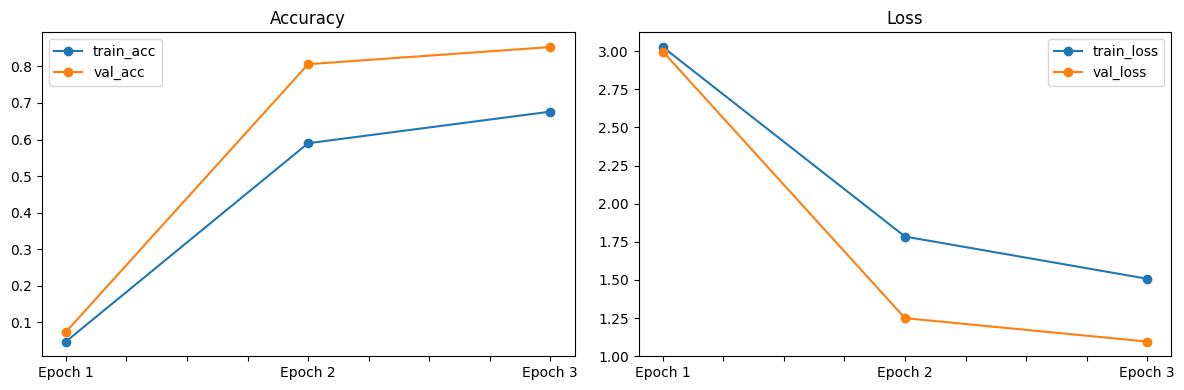

Training curves saved.


In [14]:
# ── CELL 9: Training curves ─────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import os, torch

# Detect which arch was used (depends on whether GPU was available)
arch = 'efficientnet_b0' if torch.cuda.is_available() else 'mobilenet_v3_small'

df = pd.DataFrame(history).round(4)
df.index = [f'Epoch {i+1}' for i in range(len(df))]
print(df.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df[['train_acc', 'val_acc']].plot(ax=ax1, marker='o', title='Accuracy')
df[['train_loss', 'val_loss']].plot(ax=ax2, marker='o', title='Loss')
plt.tight_layout()

out_dir = '/content/drive/MyDrive/idea4drive/eval_outputs'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved.')


In [15]:
# ── CELL 10: Evaluate on PV val (source) AND PlantDoc (target) ──────
import sys, os, torch
sys.path.append('/content/drive/MyDrive/idea4drive')

import importlib, evaluate as _ev
importlib.reload(_ev)
from evaluate import evaluate

# Auto-detect which checkpoint to use based on device/arch
arch = 'efficientnet_b0' if torch.cuda.is_available() else 'mobilenet_v3_small'
CKPT = f'/content/drive/MyDrive/idea4drive/checkpoints/best_{arch}.pth'
PV_VAL = '/content/final_dataset/val'
PD_VAL = '/content/plantdoc_aligned/val'
OUTPUT_DIR = '/content/drive/MyDrive/idea4drive/eval_outputs'

# Guard: rebuild datasets if session restarted
for path, name in [(PV_VAL, 'PV val'), (PD_VAL, 'PlantDoc aligned val')]:
    if not os.path.isdir(path):
        raise RuntimeError(f'{name} not found at {path} — re-run Cell 6 first.')
if not os.path.isfile(CKPT):
    raise RuntimeError(f'Checkpoint not found: {CKPT} — run Cell 8 first.')

pv_imgs = sum(len(os.listdir(os.path.join(PV_VAL, c))) for c in os.listdir(PV_VAL) if os.path.isdir(os.path.join(PV_VAL, c)))
pd_imgs = sum(len(os.listdir(os.path.join(PD_VAL, c))) for c in os.listdir(PD_VAL) if os.path.isdir(os.path.join(PD_VAL, c)))
print(f'PV val:     OK ({pv_imgs} images)')
print(f'PD aligned: OK ({pd_imgs} images)')
print(f'Checkpoint: OK ({os.path.getsize(CKPT)/1e6:.1f} MB) — arch: {arch}')
print()

eval_results = evaluate(
    checkpoint_path = CKPT,
    pv_val_dir      = PV_VAL,
    pd_eval_dir     = PD_VAL,
    arch            = arch,
    batch_size      = 32,
    output_dir      = OUTPUT_DIR,
)
print('\nEvaluation complete. Results saved to Drive.')


PV val:     OK (4743 images)
PD aligned: OK (1679 images)
Checkpoint: OK (10.5 MB) — arch: mobilenet_v3_small




Evaluation complete. Results saved to Drive.


In [16]:
import sys
sys.path.append('/content/drive/MyDrive/idea4drive')

In [17]:
# ── CELL 11: Domain gap analysis ────────────────────────────────────
import os, sys, torch, importlib
sys.path.append('/content/drive/MyDrive/idea4drive')

import domain_gap as _dg, evaluate as _ev
importlib.reload(_dg)
importlib.reload(_ev)
from domain_gap import compute_domain_gap
from evaluate import evaluate, load_model_from_checkpoint

# Auto-detect arch
arch = 'efficientnet_b0' if torch.cuda.is_available() else 'mobilenet_v3_small'
CKPT       = f'/content/drive/MyDrive/idea4drive/checkpoints/best_{arch}.pth'
PV_VAL     = '/content/final_dataset/val'
PD_VAL     = '/content/plantdoc_aligned/val'
OUTPUT_DIR = '/content/drive/MyDrive/idea4drive/eval_outputs'

# Guards
for path, name in [(PV_VAL, 'PV val'), (PD_VAL, 'PD val')]:
    if not os.path.isdir(path):
        raise RuntimeError(f'{name} not found — re-run Cell 6 first.')
if not os.path.isfile(CKPT):
    raise RuntimeError(f'Checkpoint not found: {CKPT} — run Cell 8 first.')

# Auto-run evaluation if eval_results not in scope
if 'eval_results' not in dir() and 'eval_results' not in globals():
    print('eval_results not found — running evaluation first...')
    eval_results = evaluate(
        checkpoint_path = CKPT,
        pv_val_dir      = PV_VAL,
        pd_eval_dir     = PD_VAL,
        arch            = arch,
        batch_size      = 32,
        output_dir      = OUTPUT_DIR,
    )
    print('Evaluation complete.')
else:
    print('eval_results found — skipping re-evaluation.')

model = load_model_from_checkpoint(CKPT, arch=arch)

gap_results = compute_domain_gap(
    model           = model,
    pv_val_dir      = PV_VAL,
    pd_eval_dir     = PD_VAL,
    eval_results    = eval_results,
    output_dir      = OUTPUT_DIR,
    mmd_sample_size = 2000,
)
print('\nDomain gap analysis complete.')


eval_results found — skipping re-evaluation.



Domain gap analysis complete.


In [18]:
# ── CELL 12: Structured benchmark results table ──────────────────────────
import json, os

out = '/content/drive/MyDrive/idea4drive/eval_outputs'

pv = eval_results.get('pv_val', {})
pd_r = eval_results.get('pd_eval', {})
gap = gap_results

print('=' * 65)
print('BENCHMARK RESULTS SUMMARY — Lab-to-Field Domain Generalisation')
print('=' * 65)
print(f"{'Metric':<35} {'PV-val (source)':>18} {'PD-eval (target)':>18}")
print('-' * 65)
print(f"{'Accuracy':<35} {pv.get('accuracy',0)*100:>17.2f}% {pd_r.get('accuracy',0)*100:>17.2f}%")
print(f"{'Macro-F1':<35} {pv.get('macro_f1',0):>18.4f} {pd_r.get('macro_f1',0):>18.4f}")
print(f"{'Weighted-F1':<35} {pv.get('weighted_f1',0):>18.4f} {pd_r.get('weighted_f1',0):>18.4f}")
print(f"{'# Samples':<35} {pv.get('n_samples',0):>18d} {pd_r.get('n_samples',0):>18d}")
print('=' * 65)

drop = gap.get('performance_drop', {})
if drop:
    print(f"\nDomain Gap (PV → PD):")
    print(f"  Δ Accuracy  : {drop.get('delta_accuracy',0):+.4f}  ({drop.get('relative_accuracy_drop_pct',0):+.1f}% relative)")
    print(f"  Δ Macro-F1  : {drop.get('delta_macro_f1',0):+.4f}  ({drop.get('relative_f1_drop_pct',0):+.1f}% relative)")

mmd = gap.get('mmd', {})
cen = gap.get('centroid_distance', {})
if mmd:
    print(f"\nFeature-space gap metrics:")
    print(f"  MMD²              : {mmd.get('mmd_squared', 0):.6f}  (σ={mmd.get('sigma',0):.4f})")
    print(f"  Centroid L2 dist  : {cen.get('centroid_distance',0):.6f}")
    print(f"  Centroid cos-sim  : {cen.get('cosine_similarity',0):.6f}")

print('=' * 65)

# Save full summary JSON
summary = {
    'pv_val':  {k: v for k, v in pv.items()   if k not in ('report_str', 'confusion_matrix', '_pv_inference', '_pd_inference')},
    'pd_eval': {k: v for k, v in pd_r.items() if k not in ('report_str', 'confusion_matrix', '_pv_inference', '_pd_inference')},
    'domain_gap': gap,
}
summary_path = os.path.join(out, 'benchmark_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nFull summary saved to: {summary_path}')

BENCHMARK RESULTS SUMMARY — Lab-to-Field Domain Generalisation
Metric                                 PV-val (source)   PD-eval (target)
-----------------------------------------------------------------
Accuracy                                        85.28%             22.51%
Macro-F1                                        0.8198             0.1830
Weighted-F1                                     0.8509             0.2065
# Samples                                         4743               1679

Domain Gap (PV → PD):
  Δ Accuracy  : +0.6277  (+73.6% relative)
  Δ Macro-F1  : +0.6368  (+77.7% relative)

Feature-space gap metrics:
  MMD²              : 0.137288  (σ=0.6938)
  Centroid L2 dist  : 0.400632
  Centroid cos-sim  : 0.861094

Full summary saved to: /content/drive/MyDrive/idea4drive/eval_outputs/benchmark_summary.json


#**FINETUNING**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import sys
sys.path.append('/content/drive/MyDrive/idea4drive')

import importlib, finetune_plantdoc as _ft
importlib.reload(_ft)
from finetune_plantdoc import split_plantdoc, finetune_plantdoc

In [21]:
# ── CELL 13 ──────────────────────────
from finetune_plantdoc import split_plantdoc

split_plantdoc(
    src_dir = '/content/plantdoc_aligned/val',
    out_dir = '/content/plantdoc_ft',
    val_frac = 0.20,
    seed = 42,
)

(PosixPath('/content/plantdoc_ft/train'),
 PosixPath('/content/plantdoc_ft/val'))

In [22]:
# ── CELL 14 ──────────────────────────
import importlib, finetune_plantdoc as _ft
importlib.reload(_ft)
from finetune_plantdoc import finetune_plantdoc

history = finetune_plantdoc(
    checkpoint_path = '/content/drive/MyDrive/idea4drive/checkpoints/best_efficientnet_b0.pth',
    pd_train_dir    = '/content/plantdoc_ft/train',
    pd_val_dir      = '/content/plantdoc_ft/val',
    output_dir      = '/content/drive/MyDrive/idea4drive/checkpoints_ft',
    arch            = 'efficientnet_b0',   # ✅ ADD THIS LINE
    epochs          = 8,
    freeze_epochs   = 2,
    base_lr         = 1e-4,
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 83.3MB/s]



===== Epoch 1/8  [Phase 1 — head only] =====


  Train — loss: 2.8978  acc: 0.2364
  Val   — loss: 2.5633  acc: 0.3294

===== Epoch 2/8  [Phase 1 — head only] =====


  Train — loss: 2.5861  acc: 0.2877
  Val   — loss: 2.1200  acc: 0.3947

===== Epoch 3/8  [Phase 2 — full model] =====


...

  Train — loss: 2.3775  acc: 0.3245
  Val   — loss: 2.0827  acc: 0.4273

===== Epoch 5/8  [Phase 2 — full model] =====


  Train — loss: 2.2865  acc: 0.3637
  Val   — loss: 2.0260  acc: 0.4540

===== Epoch 6/8  [Phase 2 — full model] =====


  Train — loss: 2.2102  acc: 0.3803
  Val   — loss: 1.9652  acc: 0.4659

===== Epoch 7/8  [Phase 2 — full model] =====


  Train — loss: 2.2056  acc: 0.3742
  Val   — loss: 1.9356  acc: 0.4807

===== Epoch 8/8  [Phase 2 — full model] =====


  Train — loss: 2.1983  acc: 0.3870
  Val   — loss: 1.9411  acc: 0.4688


In [23]:
import json

with open('/content/drive/MyDrive/idea4drive/ft_history.json', 'w') as f:
    json.dump(history, f)

In [24]:
import os

print("Checkpoint exists:", os.path.exists('/content/drive/MyDrive/idea4drive/checkpoints_ft/ft_best_efficientnet_b0.pth'))
print("PV val samples:", len(os.listdir('/content/final_dataset/val')))
print("PD val samples:", len(os.listdir('/content/plantdoc_aligned/val')))

Checkpoint exists: True
PV val samples: 17
PD val samples: 17


In [25]:
# ── CELL 15 ──────────────────────────
import importlib, evaluate as _ev
importlib.reload(_ev)
from evaluate import evaluate

print("Starting evaluation...")

results_ft = evaluate(
    checkpoint_path='/content/drive/MyDrive/idea4drive/checkpoints_ft/ft_best_efficientnet_b0.pth',
    pv_val_dir='/content/final_dataset/val',
    pd_eval_dir='/content/plantdoc_aligned/val',
    arch='efficientnet_b0',
    output_dir='/content/drive/MyDrive/idea4drive/eval_outputs_ft'   # ✅ ADD THIS
)

print("Evaluation finished.")

Starting evaluation...


Evaluation finished.


In [26]:
# ── CELL 16 ──────────────────────────
# — FT Structured benchmark results table —

import json, os

out = '/content/drive/MyDrive/idea4drive/eval_outputs_ft'   # ✅ changed

# Load eval results
with open(os.path.join(out, 'pv_val_results.json')) as f:
    pv = json.load(f)

with open(os.path.join(out, 'pd_eval_results.json')) as f:
    pd_r = json.load(f)

# Load domain gap results (if exists)
gap_path = os.path.join(out, 'domain_gap_results.json')
gap = {}
if os.path.exists(gap_path):
    with open(gap_path) as f:
        gap = json.load(f)

print('=' * 65)
print('FT BENCHMARK RESULTS SUMMARY')
print('=' * 65)
print(f"{'Metric':<35} {'PV-val (source)':>18} {'PD-eval (target)':>18}")
print('-' * 65)

print(f"{'Accuracy':<35} {pv.get('accuracy',0)*100:>17.2f}% {pd_r.get('accuracy',0)*100:>17.2f}%")
print(f"{'Macro-F1':<35} {pv.get('macro_f1',0):>18.4f} {pd_r.get('macro_f1',0):>18.4f}")
print(f"{'Weighted-F1':<35} {pv.get('weighted_f1',0):>18.4f} {pd_r.get('weighted_f1',0):>18.4f}")
print(f"{'# Samples':<35} {pv.get('n_samples',0):>18} {pd_r.get('n_samples',0):>18}")
print('=' * 65)

# Save summary JSON
summary = {
    'pv_val': pv,
    'pd_eval': pd_r,
    'domain_gap': gap
}

summary_path = os.path.join(out, 'benchmark_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nFull summary saved to: {summary_path}")

FT BENCHMARK RESULTS SUMMARY
Metric                                 PV-val (source)   PD-eval (target)
-----------------------------------------------------------------
Accuracy                                        86.53%             49.02%
Macro-F1                                        0.8136             0.4341
Weighted-F1                                     0.8615             0.4828
# Samples                                         4743               1679

Full summary saved to: /content/drive/MyDrive/idea4drive/eval_outputs_ft/benchmark_summary.json


In [27]:
# ── CELL 17 ──────────────────────────
import importlib, domain_gap as _dg
importlib.reload(_dg)
from domain_gap import compute_domain_gap

# 🔹 load model first (IMPORTANT)
from evaluate import load_model_from_checkpoint

model = load_model_from_checkpoint(
    checkpoint_path='/content/drive/MyDrive/idea4drive/checkpoints_ft/ft_best_efficientnet_b0.pth',
    arch='efficientnet_b0'
)

print("Starting domain gap computation...")

gap_results_ft = compute_domain_gap(
    model=model,   # ✅ FIXED
    pv_val_dir='/content/final_dataset/val',
    pd_eval_dir='/content/plantdoc_aligned/val',
    eval_results=results_ft,
    output_dir='/content/drive/MyDrive/idea4drive/eval_outputs_ft'
)

print("Domain gap computation finished.")

Starting domain gap computation...


Domain gap computation finished.


In [28]:
# ── CELL 18: Structured benchmark results table ──────────────────────────
# — FT Domain Gap Summary —

import json, os

out = '/content/drive/MyDrive/idea4drive/eval_outputs_ft'

# Load domain gap results
gap_path = os.path.join(out, 'domain_gap_results.json')

if not os.path.exists(gap_path):
    raise FileNotFoundError("Run domain_gap cell first — file not found.")

with open(gap_path) as f:
    gap = json.load(f)

print('=' * 65)
print('FT DOMAIN GAP SUMMARY')
print('=' * 65)

# --- Performance drop ---
drop = gap.get('performance_drop', {})

print('\nPerformance Drop (PV → PD):')
print(f"  Δ Accuracy      : {drop.get('delta_accuracy',0):.4f} ({drop.get('relative_accuracy_drop_pct',0):.1f}% relative)")
print(f"  Δ Macro-F1      : {drop.get('delta_macro_f1',0):.4f} ({drop.get('relative_f1_drop_pct',0):.1f}% relative)")
print(f"  Δ Weighted-F1   : {drop.get('delta_weighted_f1',0):.4f}")

# --- Feature gap ---
mmd = gap.get('mmd', {})
cen = gap.get('centroid_distance', {})

print('\nFeature-space Gap:')
print(f"  MMD²            : {mmd.get('mmd_squared',0):.6f} (σ={mmd.get('sigma',0):.4f})")
print(f"  Centroid L2     : {cen.get('centroid_distance',0):.6f}")
print(f"  Cosine Similarity: {cen.get('cosine_similarity',0):.6f}")

print('=' * 65)

# Save a cleaner summary JSON (optional but useful)
summary = {
    'performance_drop': drop,
    'feature_gap': {
        'mmd_squared': mmd.get('mmd_squared',0),
        'centroid_distance': cen.get('centroid_distance',0),
        'cosine_similarity': cen.get('cosine_similarity',0)
    }
}

summary_path = os.path.join(out, 'domain_gap_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nDomain gap summary saved to: {summary_path}")

FT DOMAIN GAP SUMMARY

Performance Drop (PV → PD):
  Δ Accuracy      : 0.3751 (43.4% relative)
  Δ Macro-F1      : 0.3795 (46.6% relative)
  Δ Weighted-F1   : 0.3787

Feature-space Gap:
  MMD²            : 0.079168 (σ=0.9454)
  Centroid L2     : 0.415771
  Cosine Similarity: 0.523676

Domain gap summary saved to: /content/drive/MyDrive/idea4drive/eval_outputs_ft/domain_gap_summary.json


In [6]:
# ── CELL 19: Structured benchmark results table ──────────────────────────
exec(open('/content/drive/MyDrive/idea4drive/benchmark_comparison.py').read())


Loading evaluation JSONs...

  BENCHMARK COMPARISON — Source-Only vs. Fine-Tuned
  Metric                            Source-Only (Baseline)   Fine-Tuned (PlantDoc)
----------------------------------------------------------------------------------
  PV Accuracy (source, in-dist)                     85.28%                  86.53%
  PD Accuracy (target, OOD)                         22.51%                  49.02%
  Δ Accuracy (domain gap)                           0.6277                  0.3751
  Relative Accuracy Drop (%)                         73.6%                   43.4%

  PV Macro-F1 (source)                              0.8198                  0.8136
  PD Macro-F1 (target)                              0.1830                  0.4341
  Δ Macro-F1                                        0.6368                  0.3795
  Relative F1 Drop (%)                               77.7%                   46.6%

  MMD² (feature-space gap)                        0.137288                0.079168
  C

## **The model performs well on PlantVillage (lab data) but poorly on PlantDoc (real-world data), clearly indicating a significant domain gap. In the baseline setting, accuracy drops from ~85% on PlantVillage to ~22% on PlantDoc, showing that the model fails to generalize across domains. This gap arises due to differences in background, lighting conditions, noise, and viewing angles between controlled lab images and real-world field images. Applying stronger augmentations did not significantly improve performance, confirming that regularization alone is insufficient. However, supervised fine-tuning on PlantDoc improves accuracy to ~49%, reducing the domain gap substantially and showing that adapting to the target distribution helps. Overall, these results demonstrate that domain shift is the primary challenge, rather than limitations in model capacity.**